# Multimodal Parser Demo

Test parsing, indexing, and RAG agent functionalities.

In [1]:
from dotenv import load_dotenv
load_dotenv("../.env")
from IPython.display import Image as IPImage, display
from multimodal_parser import DoclingParser, ChunkType, RAGAgent, render
from multimodal_parser.indexer import DocumentIndexer

## 1. Parse PDF

In [2]:
parser = DoclingParser()
chunks = parser.parse("../data/files/rag_paper.pdf")

text_chunks = [c for c in chunks if c.chunk_type == ChunkType.TEXT]
table_chunks = [c for c in chunks if c.chunk_type == ChunkType.TABLE]
image_chunks = [c for c in chunks if c.chunk_type == ChunkType.IMAGE]

print(f"Total: {len(chunks)} | Text: {len(text_chunks)} | Tables: {len(table_chunks)} | Images: {len(image_chunks)}")

INFO:multimodal_parser.docling_parser:ModelManager initialized for AI descriptions
INFO:multimodal_parser.docling_parser:Parsing: ../data/files/rag_paper.pdf
INFO:docling.datamodel.document:detected formats: [<InputFormat.PDF: 'pdf'>]
INFO:docling.document_converter:Going to convert document batch...
INFO:docling.document_converter:Initializing pipeline for StandardPdfPipeline with options hash e62bb61b618fb4175c3572edceab1bfb
INFO:docling.models.factories.base_factory:Loading plugin 'docling_defaults'
INFO:docling.models.factories:Registered picture descriptions: ['vlm', 'api']
INFO:docling.models.factories.base_factory:Loading plugin 'docling_defaults'
INFO:docling.models.factories:Registered ocr engines: ['auto', 'easyocr', 'ocrmac', 'rapidocr', 'tesserocr', 'tesseract']
INFO:docling.models.stages.ocr.auto_ocr_model:Auto OCR model selected ocrmac.
INFO:docling.models.factories.base_factory:Loading plugin 'docling_defaults'
INFO:docling.models.factories:Registered layout engines: ['d

Total: 45 | Text: 34 | Tables: 7 | Images: 4


In [22]:
# Sample text chunk
if text_chunks:
    c = text_chunks[10]
    print("\n[TEXT CHUNK]")
    print(c)


[TEXT CHUNK]
chunk_id='text_10' chunk_type=<ChunkType.TEXT: 'text'> content="3.1 Open-domain Question Answering\nOpen-domain question answering (QA) is an important real-world application and common testbed for knowledge-intensive tasks [20]. We treat questions and answers as input-output text pairs ( x, y ) and train RAG by directly minimizing the negative log-likelihood of answers. We compare RAG to the popular extractive QA paradigm [5, 7, 31, 26], where answers are extracted spans from retrieved documents, relying primarily on non-parametric knowledge. We also compare to 'Closed-Book QA' approaches [52], which, like RAG, generate answers, but which do not exploit retrieval, instead relying purely on parametric knowledge. We consider four popular open-domain QA datasets: Natural Questions (NQ) [29], TriviaQA (TQA) [24]. WebQuestions (WQ) [3] and CuratedTrec (CT) [2]. As CT and WQ are small, we follow DPR [26] by initializing CT and WQ models with our NQ RAG model. We use the same t

In [46]:
# Sample table chunk
if table_chunks:
    c = table_chunks[1]
    print("\n[TABLE CHUNK]")
    print(c)


[TABLE CHUNK]
chunk_id='table_36' chunk_type=<ChunkType.TABLE: 'table'> content='This table presents numerical performance scores for various Natural Language Processing (NLP) machine learning models (SotA, BART, RAG-Tok, RAG-Seq) on text generation and classification tasks. It details metrics' sequence_number=36 source_document='rag_paper.pdf' source_page=6 parent_heading='4.1 Open-domain Question Answering' extraction_timestamp=datetime.datetime(2026, 2, 3, 18, 51, 13, 71936) dataframe=         Model.Model Jeopardy.B-1 Jeopardy.QB-1 MSMARCO.R-L MSMARCO.B-1  \
0               SotA            -             -      49.8 *      49.9 *   
1               BART         15.1          19.7        38.2        41.6   
2  RAG-Tok. RAG-Seq.         17.3          22.2        40.1        41.5   
3                            14.7          21.4        40.8        44.2   

  FVR3.Label FVR2 Acc..Label  
0       76.8          92.2 *  
1       64.0            81.1  
2       72.5            89.5  
3     

In [9]:
# Sample image chunk
if image_chunks:
    c = image_chunks[0]
    print("\n[IMAGE CHUNK]")
    if c.image_path:
        display(IPImage(filename=c.image_path, width=400))
    print(c)

## 2. Index to Qdrant

In [2]:
indexer = DocumentIndexer(qdrant_path="../qdrant_data", force_reset=True)
count = indexer.index_folder("../data/files")
print(f"Indexed {count} chunks")
indexer.close()

INFO:multimodal_parser.indexer:Cleared existing Qdrant data: ../qdrant_data
INFO:multimodal_parser.docling_parser:ModelManager initialized for AI descriptions
INFO:multimodal_parser.indexer:Created collection: document_chunks (vector_size=3072)
INFO:multimodal_parser.indexer:Found 2 files to process
INFO:multimodal_parser.docling_parser:Parsing: ../data/files/llm_as_a_judge.pdf
INFO:docling.datamodel.document:detected formats: [<InputFormat.PDF: 'pdf'>]
INFO:docling.document_converter:Going to convert document batch...
INFO:docling.document_converter:Initializing pipeline for StandardPdfPipeline with options hash e62bb61b618fb4175c3572edceab1bfb
INFO:docling.models.factories.base_factory:Loading plugin 'docling_defaults'
INFO:docling.models.factories:Registered picture descriptions: ['vlm', 'api']
INFO:docling.models.factories.base_factory:Loading plugin 'docling_defaults'
INFO:docling.models.factories:Registered ocr engines: ['auto', 'easyocr', 'ocrmac', 'rapidocr', 'tesserocr', 'tess

Indexed 149 chunks


### View all chunks in the vector DB

Scroll every point in the `document_chunks` collection (payload only; no vectors).

In [3]:
from qdrant_client import QdrantClient
from multimodal_parser.indexer import COLLECTION_NAME
import pandas as pd

client = QdrantClient(path="../qdrant_data")
points, offset = [], None
while True:
    batch, offset = client.scroll(
        collection_name=COLLECTION_NAME,
        limit=256,
        offset=offset,
        with_payload=True,
        with_vectors=False,
    )
    points.extend(batch)
    if offset is None:
        break

rows = []
for p in points:
    pl = p.payload or {}
    rows.append({
        "chunk_type": pl.get("chunk_type"),
        "chunk_id": pl.get("chunk_id"),
        "source": pl.get("source_document"),
        "page": pl.get("source_page"),
        "preview": (pl.get("content") or ""),
    })
client.close()

print(f"Total points: {len(rows)}")
df = pd.DataFrame(rows)
df

Total points: 149


,chunk_type,chunk_id,source,page,preview
0,text,text_66,llm_as_a_judge.pdf,57,"A Survey on LLM-as-a-Judge\n- [91] Hao Liu, Ca..."
1,text,text_20,rag_paper.pdf,9,"6 Discussion\nIn this work, we presented hybri..."
2,text,text_31,llm_as_a_judge.pdf,30,4.4.2 Results and Analysis .\nComparison with ...
3,image,image_74,llm_as_a_judge.pdf,4,This is a hierarchical mind map or concept map...
4,image,image_83,llm_as_a_judge.pdf,13,This infographic is divided into two sections....
...,...,...,...,...,...
144,image,image_84,llm_as_a_judge.pdf,15,This is an architectural diagram illustrating ...
145,text,text_61,llm_as_a_judge.pdf,52,"REFERENCES\n- [1] Ayush Agrawal, Mirac Suzgun,..."
146,text,text_28,rag_paper.pdf,17,A Implementation Details\nFor Open-domain QA w...
147,text,text_15,rag_paper.pdf,6,4.2 Abstractive Question Answering\nAs shown i...


## 3. Query with RAG Agent

In [7]:
agent = RAGAgent(qdrant_path="../qdrant_data", top_k=5)

Retrieval-Augmented Generation (RAG) is a general-purpose fine-tuning approach that endows pre-trained, parametric-memory generation models with a non-parametric memory. It combines a pre-trained retriever (Dense Passage Retriever or DPR) with a pre-trained sequence-to-sequence (seq2seq) model (BART) and fine-tunes them end-to-end.

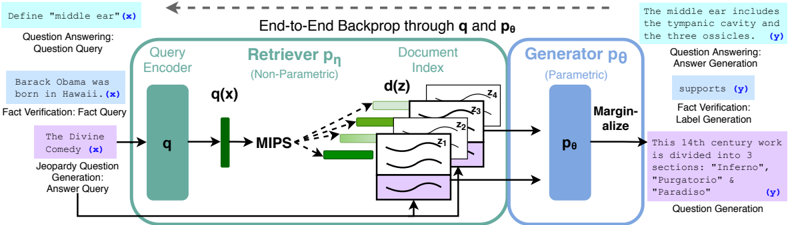

The process works as follows:
1.  An input query `x` is used by the retriever to find the top-K relevant documents `z`.
2.  The generator then conditions on these retrieved latent documents `z` along with the original input `x` to generate the target sequence `y`.
3.  RAG models treat the retrieved document as a latent variable and marginalize over these latent documents to produce a distribution over the generated text. There are two main approaches:
    *   **RAG-Sequence**: The model uses the same document to predict each target token.
    *   **RAG-Token**: The model can predict each target token based on a different retrieved document.

This combination improves factual accuracy in several ways:
*   It allows for the generation of correct answers even when documents contain clues but not the exact answer verbatim, which is not possible with standard extractive approaches.
*   RAG can generate correct answers even when the answer is not present in any retrieved document, achieving 11.8% accuracy in such cases for NQ, where an extractive model would score 0%.
*   By combining parametric and non-parametric memory, RAG addresses downsides of parametric-only models, such as their inability to easily expand or revise memory, lack of insight into predictions, and tendency to produce 'hallucinations'.
*   RAG models generate responses that are more factual, specific, and diverse compared to a BART baseline.

**Sources:** llm_as_a_judge.pdf (page 22), rag_paper.pdf (page 5), rag_paper.pdf (page 8), rag_paper.pdf (page 6), llm_as_a_judge.pdf (page 13), rag_paper.pdf (page 7), rag_paper.pdf (page 2), rag_paper.pdf (page 1), llm_as_a_judge.pdf (page 9)

In [3]:
# Text-based query
result = agent.query("What is RAG and how does it combine retrieval with generation to improve factual accuracy?")
render(result)

The architecture diagram of RAG is shown below:

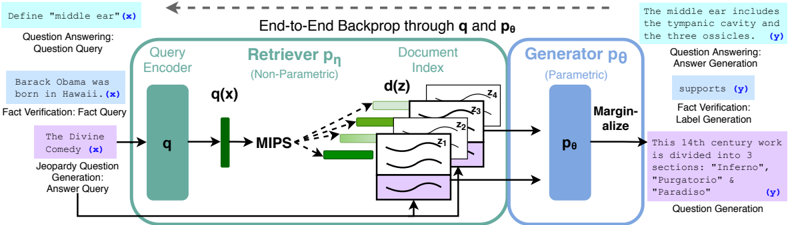

RAG models combine a retriever and a generator. The retriever, with parameters η, takes an input sequence `x` and returns a top-K truncated distribution over text passages, or documents `z`. Specifically, it uses Maximum Inner Product Search (MIPS) to find the top-K documents.

The generator, parameterized by θ, then uses these retrieved documents as additional context to generate the target sequence `y`. It generates each current token `y_i` based on the previous `i-1` tokens (`y_1:i-1`), the original input `x`, and a retrieved passage `z`.

The retrieved document `z` is treated as a latent variable, and the models marginalize over these latent documents to produce a distribution over the generated text. There are two main approaches for this marginalization:

*   **RAG-Sequence Model**: This model uses the same retrieved document to generate the complete output sequence. The generator produces the output sequence probability for each of the top K retrieved documents, and these probabilities are then marginalized.
*   **RAG-Token Model**: This model can draw a different latent document for each target token, allowing the generator to select content from multiple documents when producing an answer. The generator produces a distribution for the next output token for each document, marginalizes these distributions, and then repeats the process for the subsequent output tokens.

In essence, the retriever identifies relevant documents based on the input query, and the generator then uses these documents to inform and generate the output sequence. Both components are fine-tuned end-to-end.

**Sources:** llm_as_a_judge.pdf (page 22), rag_paper.pdf (page 3), rag_paper.pdf (page 5), rag_paper.pdf (page 8), rag_paper.pdf (page 7), rag_paper.pdf (page 2), rag_paper.pdf (page 1), llm_as_a_judge.pdf (page 20), llm_as_a_judge.pdf (page 15)

In [4]:
# Image query
result = agent.query("Show me the architecture diagram of RAG and explain how the retriever and generator components work together")
render(result)

In [5]:
# Table query
result = agent.query("From the LLM-as-a-Judge paper results table, which model has the highest agreement rate with human judges? List the top 3 models with their exact scores.")
render(result)

The top 3 models with the highest agreement rate with human judges are:

1.  o3-mini: 61.66%
2.  GPT-4-turbo: 61.54%
3.  gemini-2.0-thinking: 60.75%

**Sources:** llm_as_a_judge.pdf (page 31), llm_as_a_judge.pdf (page 13), llm_as_a_judge.pdf (page 4), llm_as_a_judge.pdf (page 25), llm_as_a_judge.pdf (page 18), llm_as_a_judge.pdf (page 34), llm_as_a_judge.pdf (page 7)

The overall framework of the LLM-as-a-Judge survey is shown below:

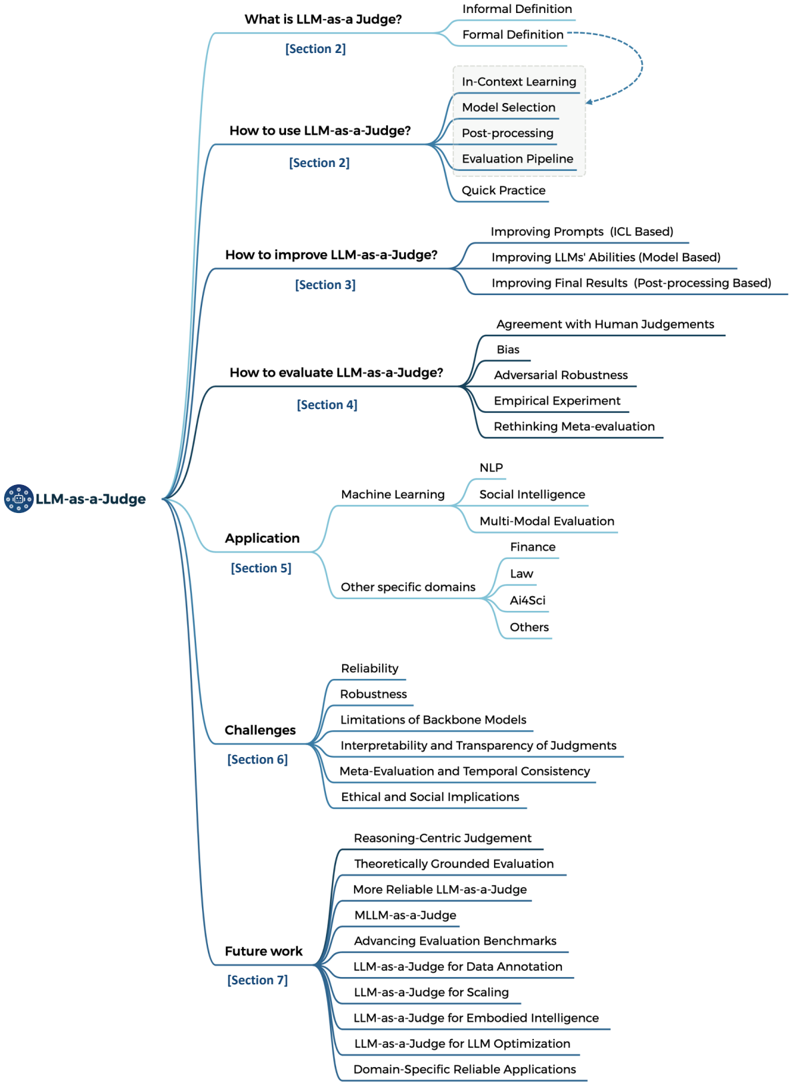

The four typical scenarios using the LLM-as-a-Judge evaluation pipeline are illustrated here:

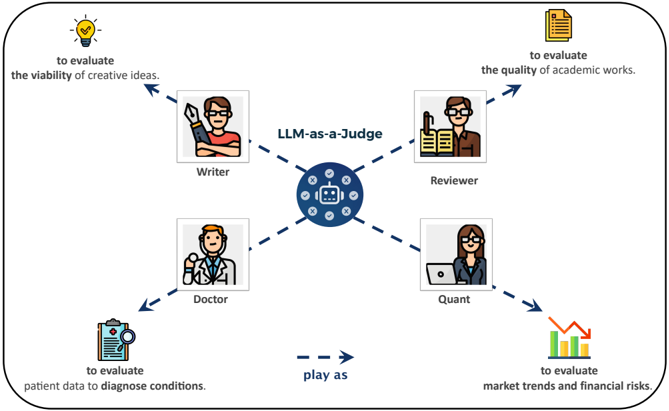

The structure for how to improve and evaluate LLM-as-a-Judge systems is presented in this image:

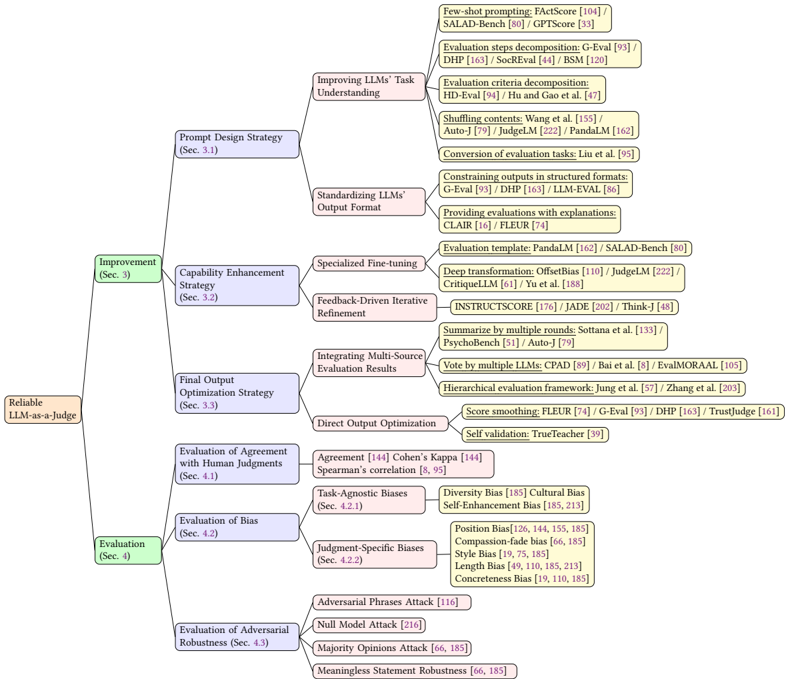

**Sources:** llm_as_a_judge.pdf (page 46), llm_as_a_judge.pdf (page 17), llm_as_a_judge.pdf (page 29), llm_as_a_judge.pdf (page 13), llm_as_a_judge.pdf (page 4), llm_as_a_judge.pdf (page 2), llm_as_a_judge.pdf (page 47), llm_as_a_judge.pdf (page 18), llm_as_a_judge.pdf (page 34), llm_as_a_judge.pdf (page 7)

In [8]:
# Multi-image (2-3) - LLM-as-a-Judge Fig 1 (framework), Fig 5 (four scenarios), Fig 9 (improvement structure)
result = agent.query("Show me the overall framework of the LLM-as-a-Judge survey, the four typical evaluation scenarios, and the structure for how to improve and evaluate LLM-as-a-Judge systems.")
render(result)
            

In [6]:
agent.close()